In [33]:
import pandas as pd
import shap
import optuna
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from sklearn.inspection import permutation_importance
import numpy as np
import talib as ta
from datetime import datetime, timezone
import config.config_binance as config
from backtest.backtester import run_backtest
from data_loader import fetch_historical_data, get_binance_client


In [2]:
# Data loader
start_dt = datetime(2024, 7, 13, tzinfo=timezone.utc)
start_ms = int(start_dt.timestamp() * 1000)

end_dt   = datetime.now(tz=timezone.utc)
end_ms   = int(end_dt.timestamp() * 1000)
df = fetch_historical_data(
            symbol=config.TRADING_SYMBOL, interval="1m", start_str=start_ms, end_str=end_ms
        )
df

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2024-07-13 00:00:00,3133.89,3135.71,3133.89,3134.21,209.5706,2024-07-13 00:00:59.999,656970.850148,883,148.3234,464938.347012
1,2024-07-13 00:01:00,3134.21,3134.21,3132.63,3132.63,26.3793,2024-07-13 00:01:59.999,82649.901070,331,5.9632,18683.445659
2,2024-07-13 00:02:00,3132.64,3133.27,3131.66,3131.74,84.2956,2024-07-13 00:02:59.999,264066.199356,552,22.2672,69758.274088
3,2024-07-13 00:03:00,3131.75,3132.24,3131.74,3131.76,44.6088,2024-07-13 00:03:59.999,139710.237263,202,37.7120,118109.879484
4,2024-07-13 00:04:00,3131.76,3132.23,3131.01,3131.01,34.4757,2024-07-13 00:04:59.999,107978.243170,394,12.0517,37744.337428
...,...,...,...,...,...,...,...,...,...,...,...
526738,2025-07-13 18:58:00,2995.29,2995.83,2994.88,2995.68,97.7184,2025-07-13 18:58:59.999,292705.497748,676,48.1341,144176.976747
526739,2025-07-13 18:59:00,2995.67,2995.68,2994.00,2994.00,60.9531,2025-07-13 18:59:59.999,182557.188296,650,8.4276,25238.109847
526740,2025-07-13 19:00:00,2994.00,2994.27,2993.48,2994.00,161.4757,2025-07-13 19:00:59.999,483433.264080,884,39.9702,119665.492966
526741,2025-07-13 19:01:00,2994.00,2994.84,2993.00,2993.22,137.5924,2025-07-13 19:01:59.999,411916.209232,1167,85.6693,256457.822547


In [3]:
data_lag = 120  # minute level data lag on binance
horizon = 60  # minutes interval after "now"
close_delayed = df["close"].shift(data_lag)
# log-return from the delayed price to (DELAY + H) minutes further out
df["log_ret_target"] = np.log(
    df["close"].shift(data_lag + horizon) / df["close"].shift(data_lag)
)

In [4]:
# Simple lin. comb. prices
df['median'] = (df['high'] + df['low']) / 2
df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3
df['weighted_close'] = (df['high'] + df['low'] + 2 * df['close']) / 4
df['ohlc_ave'] = (df['open'] + df['high'] + df['low'] + df['close']) / 4
df['high-low_range'] = df['high'] - df['low']
df['body_size'] = df['close'] - df['open']
df['upper_wick'] = df['high'] - np.maximum(df['open'], df['close'])
df['lower_wick'] = np.minimum(df['open'], df['close']) - df['low']

In [5]:
# Return & momentum features
df["ret_1"] = df["close"].pct_change()
df["log_ret_1"] = np.log(df["close"]).diff()
for w in (5, 15, 30, 60):                                  # rolling windows
    df[f"ret_{w}"] = df["close"].pct_change(w)
    df[f"mom_{w}"] = df["close"].diff(w)                 # momentum
    df[f"roc_{w}"] = df["close"].pct_change(w) * 100     # rate of change %

In [6]:
# Moving-average based signals
for w in (10, 20, 50, 200):
    df[f"sma_{w}"] = df["close"].rolling(w).mean()
    df[f"ema_{w}"] = df["close"].ewm(span=w, adjust=False).mean()
    df[f"close_above_sma_{w}"] = (df["close"] > df[f"sma_{w}"]).astype(int)
    df[f"distance_sma_{w}"] = df["close"] / df[f"sma_{w}"] - 1

In [7]:
# Volatility metrics
df["hl_range"] = df["high"] - df["low"]
df["atr_14"] = df["hl_range"].rolling(14).mean()
df["rolling_std_30"] = df["ret_1"].rolling(30).std()
df["parkinson_vol_30"] = (
    (np.log(df["high"]/df["low"])**2).rolling(30).mean() * (1/(4*np.log(2)))
).pow(0.5)          # high-low-only estimator

In [8]:
# Volume and Liquidity features
df["volume_rank_30"] = df["volume"].rank(
    pct=True, 
    method="max"
    ).rolling(30).apply(lambda x: x.iloc[-1])
df["dollar_vol"] = df["close"] * df["volume"]    # Filters out illiquid intervals
df["mean_trade_size"] = (
        df["volume"] / df["number_of_trades"].replace(0, np.nan)
    )
direction = np.sign(df["close"].diff()).fillna(0)          # -1, 0, +1
df["obv"] = (direction * df["volume"]).cumsum()
mfm = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / (df["high"] - df["low"])  # money-flow
mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0)          # handle hi==lo or NaN
df["ad_line"] = (mfm * df["volume"]).cumsum()

In [9]:
# Time-based covariates
df["minute"] = df["open_time"].dt.minute
df["hour"] = df["open_time"].dt.hour
df["dayofweek"] = df["open_time"].dt.dayofweek
df["month"] = df["open_time"].dt.month
df["is_weekend"] = df["dayofweek"] >= 5
# cyclical encoding
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

In [10]:
# Technical-indicator classics (non-linear combinations)
df["rsi_14"]  = ta.RSI(df["close"], timeperiod=14)
df["macd"], df["macd_signal"], df["macd_hist"] = ta.MACD(df["close"])
df["bb_upper"], df["bb_middle"], df["bb_lower"] = ta.BBANDS(df["close"])

In [11]:
feature_cols = [c for c in df.columns if c != "log_ret_target"]
df_model = df.dropna(subset=["log_ret_target"])
X = df_model[feature_cols]
y = df_model["log_ret_target"]

print(X.columns)
non_numeric = X.select_dtypes(exclude=["number"]).columns
print("Non-numeric columns:", list(non_numeric))
X = X.drop(columns=non_numeric)
feature_cols = [c for c in X.columns]  # feature_cols update after non numeric cols drop
assert X.select_dtypes(exclude=["number"]).empty, "Still non-numeric cols!"

def predict_price(model, latest_df, delay=120, horizon=60):
    """
    latest_df : DataFrame that **already ends at the last available candle**
                (2 h ago if you just fetched it)
    """
    latest_close = latest_df["close"].iloc[-1]                 # P(t₀)
    x_live       = latest_df[feature_cols].iloc[-1:]           # 1-row frame
    pred_log_r   = model.predict(x_live)[0]                    # r̂ (from t₀ to t₀+2h+H)
    target_price = latest_close * np.exp(pred_log_r)           # P̂(t₀+2h+H)
    return target_price

# df_live   = fetch_historical_data(..., end_str="now UTC")      # ends at t₀
# limit_px  = predict_price(trained_model, df_live)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume', 'median', 'typical_price',
       'weighted_close', 'ohlc_ave', 'high-low_range', 'body_size',
       'upper_wick', 'lower_wick', 'ret_1', 'log_ret_1', 'ret_5', 'mom_5',
       'roc_5', 'ret_15', 'mom_15', 'roc_15', 'ret_30', 'mom_30', 'roc_30',
       'ret_60', 'mom_60', 'roc_60', 'sma_10', 'ema_10', 'close_above_sma_10',
       'distance_sma_10', 'sma_20', 'ema_20', 'close_above_sma_20',
       'distance_sma_20', 'sma_50', 'ema_50', 'close_above_sma_50',
       'distance_sma_50', 'sma_200', 'ema_200', 'close_above_sma_200',
       'distance_sma_200', 'hl_range', 'atr_14', 'rolling_std_30',
       'parkinson_vol_30', 'volume_rank_30', 'dollar_vol', 'mean_trade_size',
       'obv', 'ad_line', 'minute', 'hour', 'dayofweek', 'month', 'is_weekend',
       'hour_sin', 'hour_cos', 'rsi_14', 'macd', 

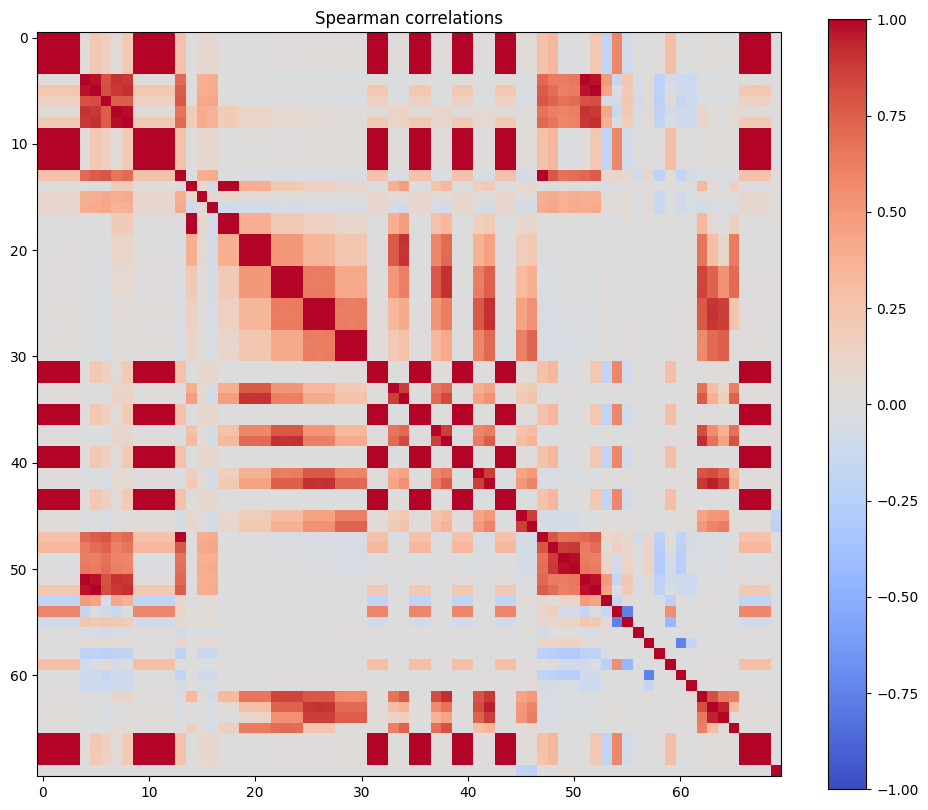

In [12]:
# Feature selection checks
corr = X.assign(target=y).corr(method="spearman")   # rank-based = robust
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(); plt.title("Spearman correlations"); plt.show()

In [18]:
tscv   = TimeSeriesSplit(n_splits=5)     # chronological CV
params = dict(
    n_estimators=1000,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.8,
    max_depth=-1,
)
model_lgbm = LGBMRegressor(**params, verbosity=-1)

# single split for simplicity; wrap in loop if you like
train_idx, test_idx = list(tscv.split(X))[-1]
model_lgbm.fit(X.iloc[train_idx], y.iloc[train_idx])
y_pred = model_lgbm.predict(X.iloc[test_idx])
print("MAE:", np.mean(np.abs(y_pred - y.iloc[test_idx])))
print("RMSE:", np.sqrt(np.mean((y_pred - y.iloc[test_idx])**2))
      )
print("SMAPE:", np.mean(
    2*np.abs(y_pred - y.iloc[test_idx])/(np.abs(y_pred)+np.abs(y.iloc[test_idx])))
    )

MAPE: 3502686114.90154
MAE: 0.004442634029571796
RMSE: 0.006488791579282236
SMAPE: 1.3580004820541884


In [14]:
model = model_lgbm

In [15]:
# Model agnostic permutative importance
perm = permutation_importance(
    model, X.iloc[test_idx], y.iloc[test_idx],
    n_repeats=10, random_state=42, scoring="neg_mean_absolute_error"
)
pi = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
print(pi.head(15))

distance_sma_200    0.001846
ret_60              0.000606
mom_60              0.000083
ema_20              0.000074
roc_60              0.000061
macd_signal         0.000043
macd                0.000035
ema_200             0.000029
distance_sma_50     0.000026
rolling_std_30      0.000014
sma_200             0.000013
parkinson_vol_30    0.000008
hour_cos            0.000007
bb_upper            0.000007
rsi_14              0.000007
dtype: float64


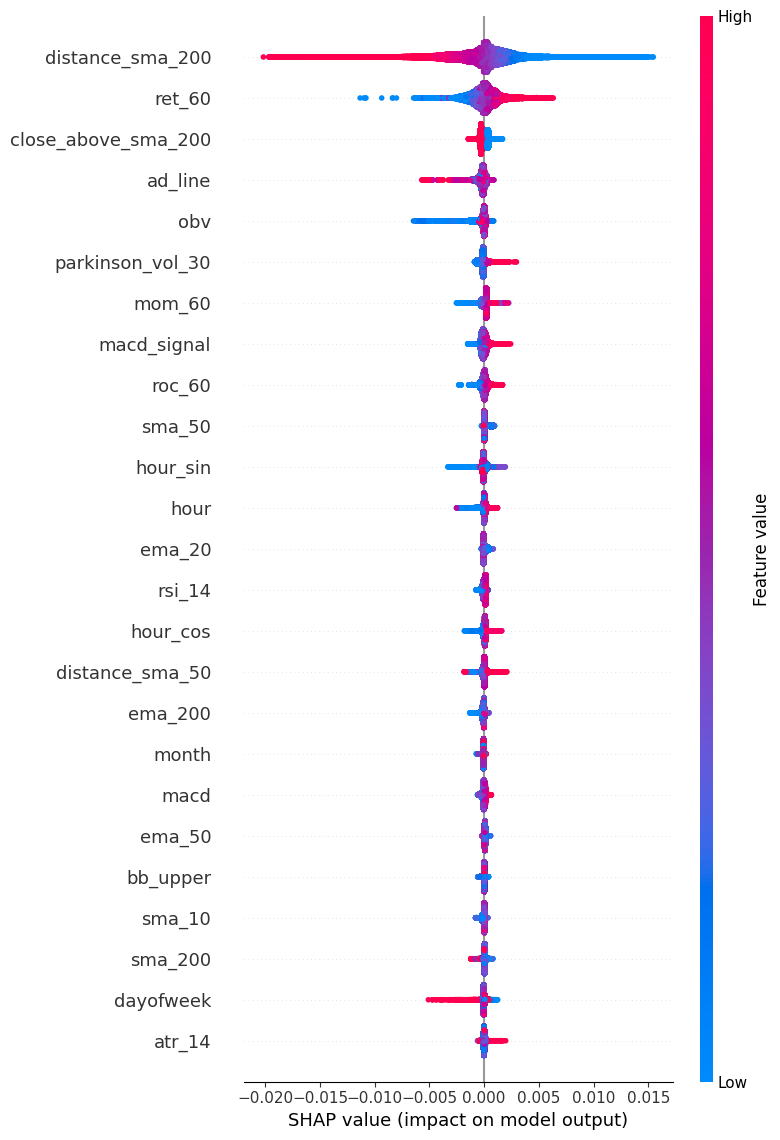

In [16]:
# Tree explainer SHAP values
expl = shap.TreeExplainer(model)
sh_values = expl.shap_values(X.iloc[test_idx])
shap.summary_plot(sh_values, X.iloc[test_idx], max_display=25)

In [20]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.5, 1.0),
    }
    # model = LGBMRegressor(**params,)
    mae_scores = []
    for train_idx, test_idx in TimeSeriesSplit(n_splits=5).split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(X.iloc[test_idx])
        mae_scores.append(mean_absolute_error(y.iloc[test_idx], y_pred))
    return np.mean(mae_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
print("Best:", study.best_params)

[I 2025-07-13 22:52:09,990] A new study created in memory with name: no-name-736c48c8-76cd-4ad0-bc54-5844071c402d
[I 2025-07-13 22:53:08,233] Trial 0 finished with value: 0.00528642413842082 and parameters: {'n_estimators': 1024, 'learning_rate': 0.004154227319886969, 'max_depth': 11, 'subsample': 0.7160922521172695, 'colsample': 0.6871917911321621}. Best is trial 0 with value: 0.00528642413842082.
[I 2025-07-13 22:54:09,374] Trial 1 finished with value: 0.00528642413842082 and parameters: {'n_estimators': 1166, 'learning_rate': 0.018815893765449933, 'max_depth': 5, 'subsample': 0.5538078053571657, 'colsample': 0.73244775693647}. Best is trial 0 with value: 0.00528642413842082.
[I 2025-07-13 22:55:16,130] Trial 2 finished with value: 0.00528642413842082 and parameters: {'n_estimators': 911, 'learning_rate': 0.0044006008270132645, 'max_depth': 8, 'subsample': 0.9396504352966389, 'colsample': 0.518764402194724}. Best is trial 0 with value: 0.00528642413842082.
[I 2025-07-13 22:56:30,456]

KeyboardInterrupt: 

In [31]:
def walk_forward(model, X, y, train_size=0.7, step=10_000):
    """
    Walk-forward evaluation that retrains every `step` rows and tests on the
    next `step` (or whatever is left at the end).

    Returns
    -------
    preds   : numpy.ndarray  concatenated predictions
    actuals : numpy.ndarray  matching ground truth
    """
    preds, actuals = [], []
    train_end = int(len(X) * train_size)

    while train_end < len(X):                       # ①  test *while* we still have data
        test_end = min(train_end + step, len(X))    # ②  clamp to frame length

        # --- fit on everything *before* the test slice --------------------
        model.fit(X.iloc[:train_end], y.iloc[:train_end])

        # --- predict the current out-of-sample block ----------------------
        y_hat = model.predict(X.iloc[train_end:test_end])
        preds.extend(y_hat)
        actuals.extend(y.iloc[train_end:test_end])

        print(f"train_end → {train_end}  test rows: {test_end-train_end}")

        train_end = test_end                        # ③  slide window forward

    return np.array(preds), np.array(actuals)

# model = LGBMRegressor(**study.best_params)
step = 10_000
p, a = walk_forward(model, X, y, step=step)

train_end → 368594  test rows: 10000
train_end → 378594  test rows: 10000
train_end → 388594  test rows: 10000
train_end → 398594  test rows: 10000
train_end → 408594  test rows: 10000
train_end → 418594  test rows: 10000
train_end → 428594  test rows: 10000
train_end → 438594  test rows: 10000
train_end → 448594  test rows: 10000
train_end → 458594  test rows: 10000
train_end → 468594  test rows: 10000
train_end → 478594  test rows: 10000
train_end → 488594  test rows: 10000
train_end → 498594  test rows: 10000
train_end → 508594  test rows: 10000
train_end → 518594  test rows: 7969


In [34]:
def slice_offsets(preds, actuals, step, offsets):
    """
    Collect y_pred and y_true at the same *offset* inside every test block.

    preds, actuals : 1-D arrays returned by walk_forward
    step           : same step you passed to walk_forward
    offsets        : list/tuple of integers (0-based offsets inside a block)

    returns dict offset → (y_true_slice, y_pred_slice)
    """
    out = {}
    n_blocks = len(preds) // step
    for off in offsets:
        idx = np.arange(off, off + n_blocks*step, step)
        out[off] = (actuals[idx], preds[idx])
    return out

mae  = mean_absolute_error(a, p)              # a = actuals, p = preds
rmse = root_mean_squared_error(a, p)

print(f"MAE  (log-return points): {mae:.6f}")
print(f"RMSE (log-return points): {rmse:.6f}")
print(f"MAE  in bp             : {mae*1e4:.2f}")
print(f"RMSE in bp             : {rmse*1e4:.2f}")


MAE  (log-return points): 0.004927
RMSE (log-return points): 0.007375
MAE  in bp             : 49.27
RMSE in bp             : 73.75


In [37]:
offsets = [0, 1, 3, 9, 29, 59]          # 1st, 2nd, 4th, 10th, 30th, 60th
slices  = slice_offsets(p, a, step, offsets)

for off, (yy, pp) in slices.items():
    print(f"\nOffset {off} (minute {off+1} of each chunk)")
    print("  rows :", len(yy))
    print("  MAE  :", mean_absolute_error(yy, pp))
    print("  RMSE :", root_mean_squared_error(yy, pp))


Offset 0 (minute 1 of each chunk)
  rows : 15
  MAE  : 0.0034557567480288033
  RMSE : 0.004178402365614921

Offset 1 (minute 2 of each chunk)
  rows : 15
  MAE  : 0.003130736871783402
  RMSE : 0.004061121247691789

Offset 3 (minute 4 of each chunk)
  rows : 15
  MAE  : 0.0026366558184794425
  RMSE : 0.0036682081153484023

Offset 9 (minute 10 of each chunk)
  rows : 15
  MAE  : 0.003137923052261851
  RMSE : 0.0038870893317686857

Offset 29 (minute 30 of each chunk)
  rows : 15
  MAE  : 0.0037660252529841593
  RMSE : 0.0050778446842499325

Offset 59 (minute 60 of each chunk)
  rows : 15
  MAE  : 0.005907845523617015
  RMSE : 0.0070660996796507265


In [ ]:
df.to_parquet(f"../data/{config.TRADING_SYMBOL}_20240713_20250713.parquet")

In [ ]:
# latest_close   = df["close"].iloc[-1]          # P_t
# pred_log_ret   = model.predict(X_live)[0]      # ŷ = r̂
# target_price   = latest_close * np.exp(pred_log_ret)